In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load hourly data (better for EDA + ARIMA)
df = pd.read_csv(
    "D:/SEM 6/TSA/Project/data/processed/power_clean_hourly.csv",
    parse_dates=["DateTime"],
    index_col="DateTime"
)

df.head()


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
DateTime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


In [5]:
df.info()
df.isna().sum()
df.describe()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 34589 entries, 2006-12-16 17:00:00 to 2010-11-26 21:00:00
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Global_active_power    34589 non-null  float64
 1   Global_reactive_power  34589 non-null  float64
 2   Voltage                34589 non-null  float64
 3   Global_intensity       34589 non-null  float64
 4   Sub_metering_1         34589 non-null  float64
 5   Sub_metering_2         34589 non-null  float64
 6   Sub_metering_3         34589 non-null  float64
dtypes: float64(7)
memory usage: 2.1 MB


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,34589.000000,34589.000000,34589.000000,34589.000000,34589.000000,34589.000000,34589.000000
mean,1.086200,0.123326,240.841505,4.604360,1.110951,1.287914,6.416515
std,0.894942,0.067221,2.999127,3.746337,3.518498,4.168720,7.344718
min,0.124000,0.000000,225.834500,0.503333,0.000000,0.000000,0.000000
25%,0.341267,0.077667,239.197167,1.510000,0.000000,0.000000,0.650000
50%,0.799533,0.106767,240.984500,3.406667,0.000000,0.333333,1.650000
75%,1.574967,0.149367,242.691833,6.583333,0.000000,0.650000,14.083333
max,6.560533,0.774333,251.902000,28.383333,48.366667,46.433333,21.550000


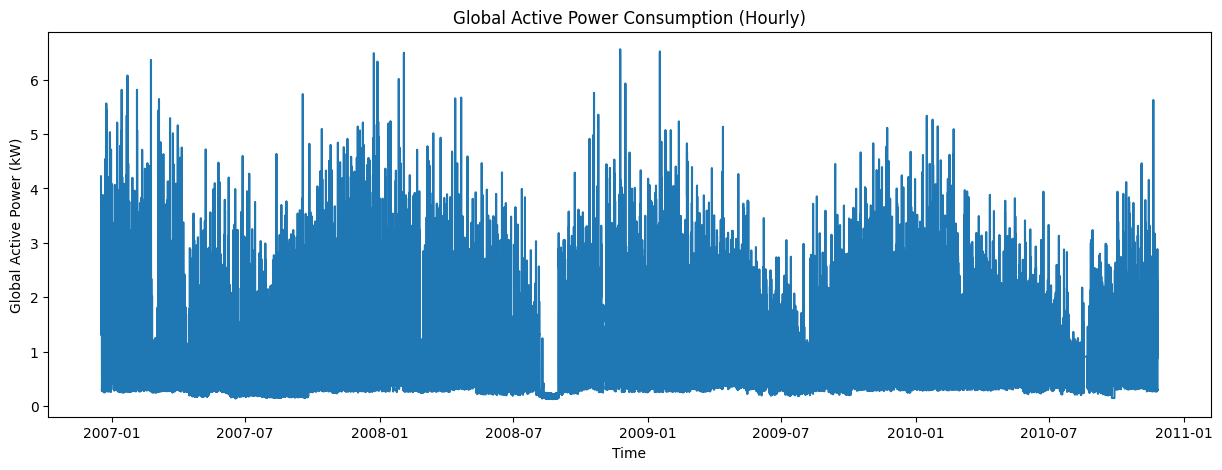

In [8]:
plt.figure(figsize=(15,5))
plt.plot(df.index, df["Global_active_power"])
plt.title("Global Active Power Consumption (Hourly)")
plt.xlabel("Time")
plt.ylabel("Global Active Power (kW)")
plt.savefig(f"{PLOT_DIR}/Global Active Power Consumption (Hourly).png", dpi=300, bbox_inches="tight")
plt.show()

plt.show()


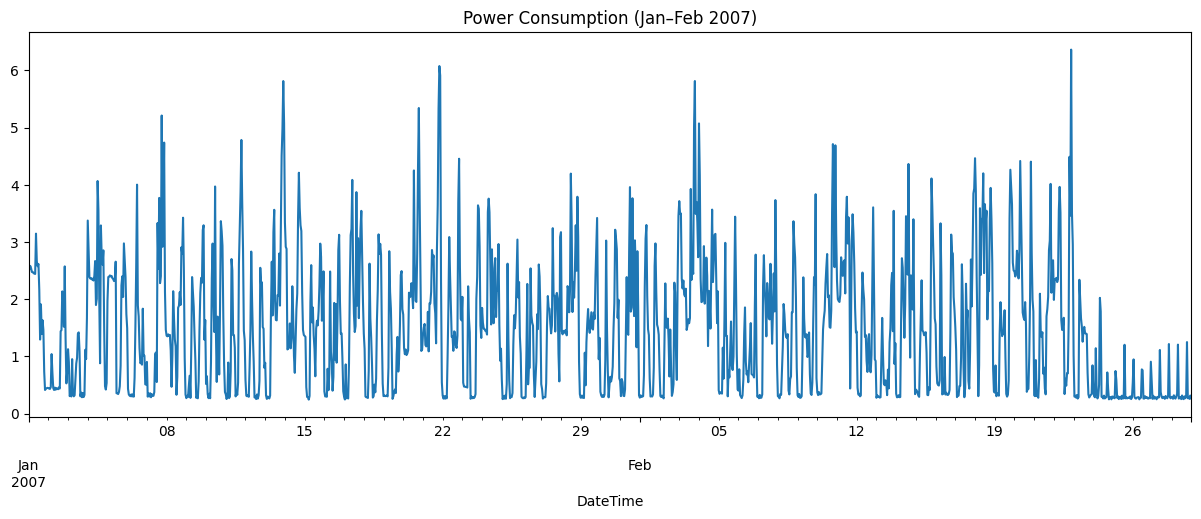

In [9]:
df["Global_active_power"]["2007-01":"2007-02"].plot(
    figsize=(15,5),
    title="Power Consumption (Jan–Feb 2007)"
)
plt.savefig(f"{PLOT_DIR}/Power Consumption (Jan–Feb 2007).png", dpi=300, bbox_inches="tight")

plt.show()


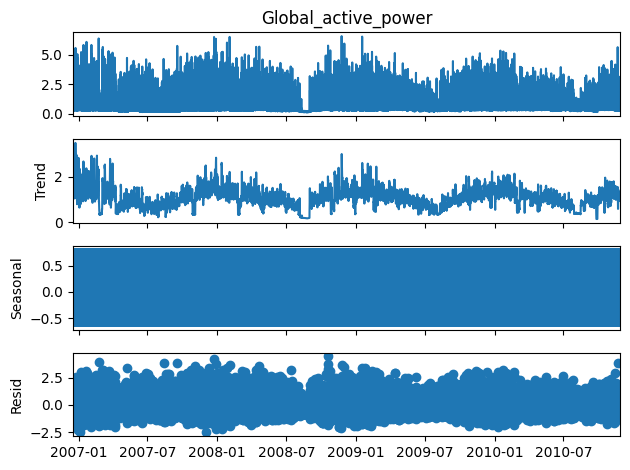

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    df["Global_active_power"],
    model="additive",
    period=24  # daily seasonality (hourly data)
)

decomposition.plot()
plt.savefig(f"{PLOT_DIR}/Global Active Power.png", dpi=300, bbox_inches="tight")

plt.show()


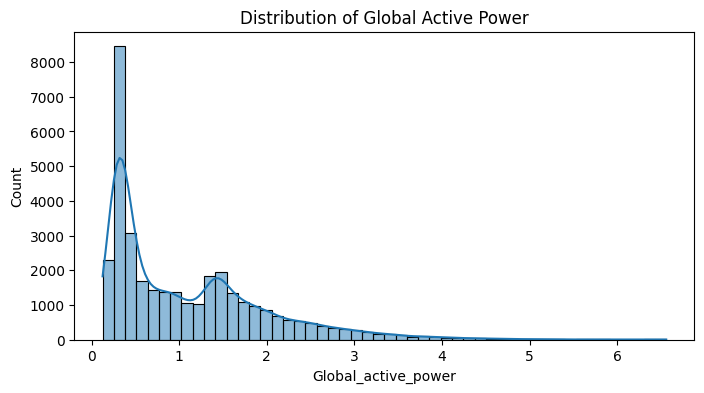

In [11]:
plt.figure(figsize=(8,4))
sns.histplot(df["Global_active_power"], bins=50, kde=True)
plt.title("Distribution of Global Active Power")
plt.savefig(f"{PLOT_DIR}/Distribution of Global Active Power.png", dpi=300, bbox_inches="tight")
plt.show()


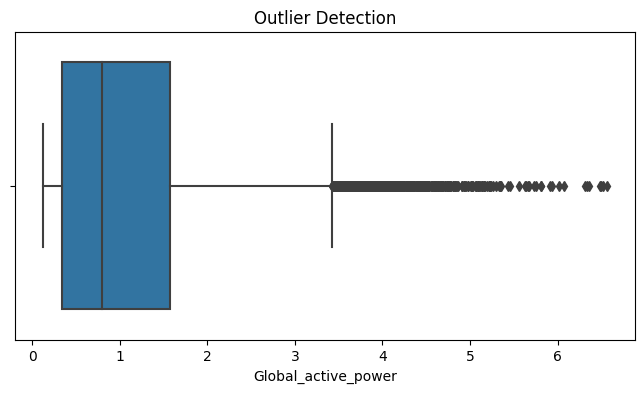

In [12]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Global_active_power"])
plt.title("Outlier Detection")
plt.savefig(f"{PLOT_DIR}/Outlier Detection.png", dpi=300, bbox_inches="tight")
plt.show()


In [11]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(df["Global_active_power"])
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])


ADF Statistic: -14.26365546825759
p-value: 1.4126108207429413e-26


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11688\32015631.py:10: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(f"{PLOT_DIR}/Rolling Mean & Std.png", dpi=300, bbox_inches="tight")


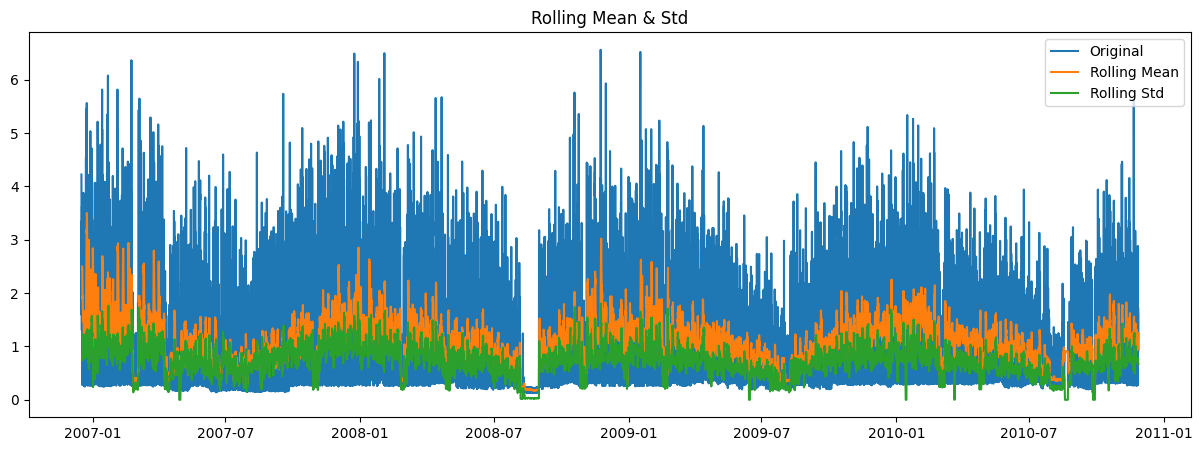

In [13]:
rolling_mean = df["Global_active_power"].rolling(window=24).mean()
rolling_std = df["Global_active_power"].rolling(window=24).std()

plt.figure(figsize=(15,5))
plt.plot(df["Global_active_power"], label="Original")
plt.plot(rolling_mean, label="Rolling Mean")
plt.plot(rolling_std, label="Rolling Std")
plt.legend()
plt.title("Rolling Mean & Std")
plt.savefig(f"{PLOT_DIR}/Rolling Mean & Std.png", dpi=300, bbox_inches="tight")
plt.show()


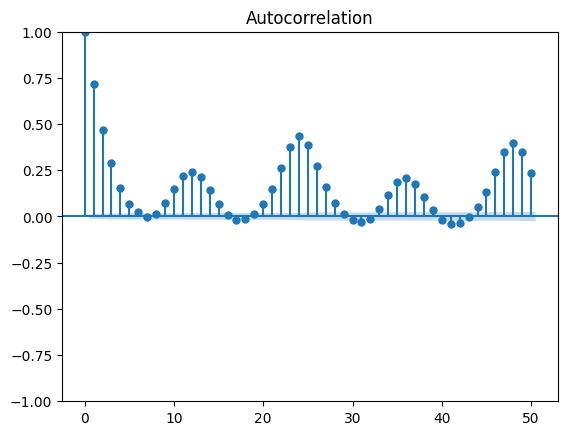

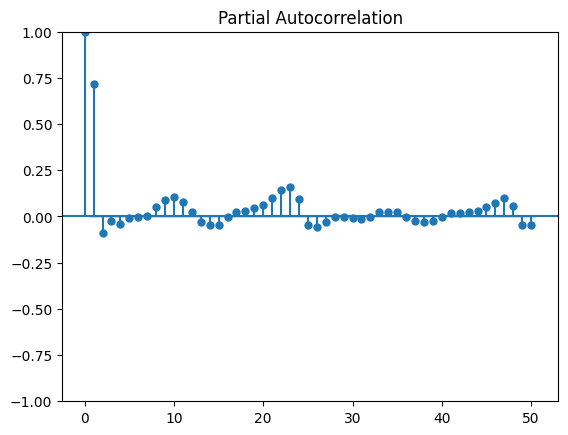

In [15]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df["Global_active_power"], lags=50)
plt.savefig(f"{PLOT_DIR}/Autocorrelation.png", dpi=300, bbox_inches="tight")
plot_pacf(df["Global_active_power"], lags=50)
plt.savefig(f"{PLOT_DIR}/Partial Autocorrelation.png", dpi=300, bbox_inches="tight")
plt.show()


In [1]:
import os

PLOT_DIR = "../results/plots"

os.makedirs(PLOT_DIR, exist_ok=True)
